# **Urban Cycling Route Planner**

In [98]:
from ipyleaflet import Map, Marker
from ipywidgets import Button, Output, VBox
import random
import time
import networkx as nx
import matplotlib.pyplot as plt

from data_handler import fill_data
from algorithms import dijkstra, a_star
from algorithms_networkx import convert_to_networkx, dijkstra_networkx, astar_networkx, betweenness_centrality
import data_structure as ds
from visualize import draw_route, draw_points

In [ ]:
m = Map(center=(47.4979, 19.0402), zoom=13)
button = Button(description="Find route", button_style="success", disabled=True)
out = Output()

coords = []
def handle_click(**kwargs):
    if kwargs.get('type') == 'click':
        active_markers = [layer for layer in m.layers if isinstance(layer, Marker)]
        latlon = kwargs.get('coordinates')

        if len(active_markers) < 2:
            marker = Marker(location=latlon)
            m.add_layer(marker)
        else:
            m.remove_layer(active_markers[0])
            marker = Marker(location=latlon)
            m.add_layer(marker)

        active_markers = len([layer for layer in m.layers if isinstance(layer, Marker)])
        button.disabled = (active_markers != 2)
def handle_button_click(b):
    with out:
        out.clear_output()
        markers = [layer for layer in m.layers if isinstance(layer, Marker)]
        start_coords = markers[0].location
        end_coords = markers[1].locatio
        start_node = closest_node_calculation(network, start_coords[0], start_coords[1])
        end_node = closest_node_calculation(network, end_coords[0], end_coords[1])
        
        path, dist = dijkstra_networkx(graph, start_node, end_node)

        draw_route(network, path)

button.on_click(handle_button_click)        
m.on_interaction(handle_click)

VBox([m, button, out])

In [100]:
areas = [
    "IX. kerület",        # smaller district
    "XI. kerület",        # medium district
    "Budapest",           # full city
    "Amsterdam",          # larger city
]

In [101]:
def benchmark_algorithms(network, nx_graph, num_samples=30):
    dijkstra_times = []
    astar_times = []
    dnetworkx_times = []
    anetworkx_times = []

    all_node_ids = list(network.nodes.keys())
    samples_collected = 0

    while samples_collected < num_samples:
        start = random.choice(all_node_ids)
        end = random.choice(all_node_ids)

        if start == end:
            continue

        # Dijkstra
        t0 = time.perf_counter()
        path, dist = dijkstra(start, end, network)
        t1 = time.perf_counter()
        if path is None:
            continue
        dijkstra_times.append(t1 - t0)

        # A*
        t0 = time.perf_counter()
        a_star(start, end, network)
        t1 = time.perf_counter()
        astar_times.append(t1 - t0)

        # NetworkX Dijkstra
        t0 = time.perf_counter()
        dijkstra_networkx(nx_graph, start, end)
        t1 = time.perf_counter()
        dnetworkx_times.append(t1 - t0)

        # NetworkX A_star
        t0 = time.perf_counter()
        astar_networkx(nx_graph, start, end)
        t1 = time.perf_counter()
        anetworkx_times.append(t1 - t0)

        samples_collected += 1

    return (
            sum(dijkstra_times) / len(dijkstra_times),
            sum(astar_times) / len(astar_times),
            sum(dnetworkx_times) / len(dnetworkx_times),
            sum(anetworkx_times) / len(anetworkx_times)
        )

In [102]:
results = []

for area in areas:
    network = fill_data(area)

    if network == "error":
        print("Error fetching data")
        continue
    
    nx_graph = convert_to_networkx(network)

    node_count = len(network.nodes)
    edge_count = len(network.ways)

    print(f"Benchmarking {node_count} nodes:")
    avg_d, avg_a, avg_dnx, avg_anx = benchmark_algorithms(network, nx_graph, num_samples=50)

    results.append({
        "area": area,
        "nodes": node_count,
        "dijkstra": avg_d,
        "a_star": avg_a,
        "networkx_dijkstra": avg_dnx,
        "networkx_astar": avg_anx

    })
    
    print(f"Result: Dijkstra: {round(avg_d, 5)}  A*: {round(avg_a, 5)}  NetworkX - Dijkstra: {round(avg_dnx, 5)} NetworkX - A*: {round(avg_anx, 5)}")

Error fetching data
Benchmarking 4615 nodes:
Result: Dijkstra: 0.00148  A*: 0.00075  NetworkX - Dijkstra: 0.00239 NetworkX - A*: 0.00143
Error fetching data


KeyboardInterrupt: 

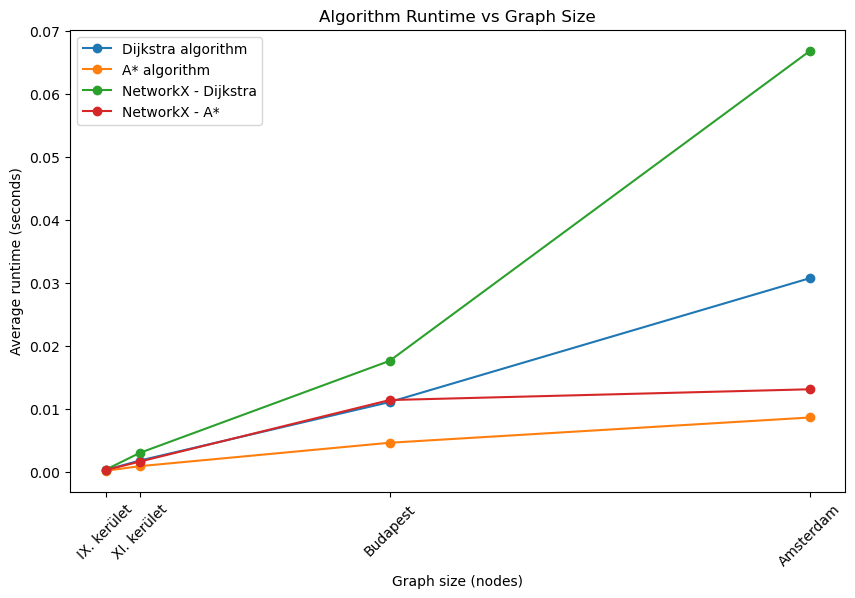

In [ ]:
nodes = [r["nodes"] for r in results]
labels = [r["area"] for r in results]

plt.figure(figsize=(10, 6))

plt.plot(nodes, [r["dijkstra"] for r in results], marker='o', label="Dijkstra algorithm")
plt.plot(nodes, [r["a_star"] for r in results], marker='o', label="A* algorithm")
plt.plot(nodes, [r["networkx_dijkstra"] for r in results], marker='o', label="NetworkX - Dijkstra")
plt.plot(nodes, [r["networkx_astar"] for r in results], marker='o', label="NetworkX - A*")

plt.xticks(nodes, labels, rotation=45)
plt.xlabel("Graph size (nodes)")
plt.ylabel("Average runtime (seconds)")
plt.title("Algorithm Runtime vs Graph Size")
plt.legend()
plt.show()

In [ ]:
network = fill_data('Budapest')

if network == "error":
    print("Error fetching data")

graph = convert_to_networkx(network)

start = 12700325860
end = 1613332399

path_dijkstra, len_dijkstra = dijkstra(start, end, network)
path_astar, len_astar = a_star(start, end, network)
path_nxdijkstra, len_nxdijkstra = dijkstra_networkx(graph, start, end)
path_nxastar, len_nxastar = astar_networkx(graph, start, end)

print(path_dijkstra == path_astar)
print(path_nxdijkstra == path_nxastar)
print(path_nxastar == path_dijkstra)

print(len_dijkstra-len_astar)
print(len_nxastar-len_nxdijkstra)
print(len_nxastar-len_dijkstra)

True
True
True
0.0
0.0
0.0
